In [94]:
import plotly.express as px

In [46]:
import pandas as pd

In [47]:
data = pd.read_excel("financial data.xlsx")
data

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing,Sale Price,Gross Sales,Discounts,Sales,Cogs,Profit,Date,Month Number,Month Name,Year
0,Government,United States of America,Paseo,Low,3450.0,10,350,1207500.0,48300.00,1159200.00,897000.0,262200.00,2014-07-01,7,July,2014
1,Small Business,Canada,Montana,Medium,3802.5,5,300,1140750.0,102667.50,1038082.50,950625.0,87457.50,2014-04-01,4,April,2014
2,Small Business,Canada,Velo,Medium,3793.5,120,300,1138050.0,102424.50,1035625.50,948375.0,87250.50,2014-07-01,7,July,2014
3,Small Business,United States of America,Paseo,High,3495.0,10,300,1048500.0,125820.00,922680.00,873750.0,48930.00,2014-01-01,1,January,2014
4,Government,Germany,Velo,Low,2966.0,120,350,1038100.0,20762.00,1017338.00,771160.0,246178.00,2013-10-01,10,October,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,Government,Germany,Carretera,Medium,1016.0,3,7,7112.0,355.60,6756.40,5080.0,1676.40,2013-11-01,11,November,2013
650,Channel Partners,Mexico,Paseo,High,571.0,10,12,6852.0,890.76,5961.24,1713.0,4248.24,2014-07-01,7,July,2014
651,Channel Partners,Mexico,Carretera,Medium,562.0,3,12,6744.0,404.64,6339.36,1686.0,4653.36,2014-09-01,9,September,2014
652,Government,Mexico,Paseo,NaN,883.0,10,7,6181.0,0.00,6181.00,4415.0,1766.00,2014-08-01,8,August,2014


In [48]:
data.isna().sum()

Segment           0
Country           0
Product           0
Discount Band    51
Units Sold        0
Manufacturing     0
Sale Price        0
Gross Sales       0
Discounts         0
Sales             0
Cogs              0
Profit            0
Date              0
Month Number      0
Month Name        0
Year              0
dtype: int64

In [49]:
data.drop_duplicates()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing,Sale Price,Gross Sales,Discounts,Sales,Cogs,Profit,Date,Month Number,Month Name,Year
0,Government,United States of America,Paseo,Low,3450.0,10,350,1207500.0,48300.00,1159200.00,897000.0,262200.00,2014-07-01,7,July,2014
1,Small Business,Canada,Montana,Medium,3802.5,5,300,1140750.0,102667.50,1038082.50,950625.0,87457.50,2014-04-01,4,April,2014
2,Small Business,Canada,Velo,Medium,3793.5,120,300,1138050.0,102424.50,1035625.50,948375.0,87250.50,2014-07-01,7,July,2014
3,Small Business,United States of America,Paseo,High,3495.0,10,300,1048500.0,125820.00,922680.00,873750.0,48930.00,2014-01-01,1,January,2014
4,Government,Germany,Velo,Low,2966.0,120,350,1038100.0,20762.00,1017338.00,771160.0,246178.00,2013-10-01,10,October,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,Government,Germany,Carretera,Medium,1016.0,3,7,7112.0,355.60,6756.40,5080.0,1676.40,2013-11-01,11,November,2013
650,Channel Partners,Mexico,Paseo,High,571.0,10,12,6852.0,890.76,5961.24,1713.0,4248.24,2014-07-01,7,July,2014
651,Channel Partners,Mexico,Carretera,Medium,562.0,3,12,6744.0,404.64,6339.36,1686.0,4653.36,2014-09-01,9,September,2014
652,Government,Mexico,Paseo,NaN,883.0,10,7,6181.0,0.00,6181.00,4415.0,1766.00,2014-08-01,8,August,2014


In [50]:
data.dtypes

Segment                  object
Country                  object
Product                  object
Discount Band            object
Units Sold              float64
Manufacturing             int64
Sale Price                int64
Gross Sales             float64
Discounts               float64
Sales                   float64
Cogs                    float64
Profit                  float64
Date             datetime64[ns]
Month Number              int64
Month Name               object
Year                      int64
dtype: object

In [51]:
#rounding off
data["Sales"] = data["Sales"].round()

In [52]:
#converting to integer
data["Sales"] = data["Sales"].astype(int)

In [53]:
#get the total sales by country
a = data.groupby("Country").sum(numeric_only=True)["Sales"].reset_index()
a

,Country,Sales
0,Canada,24856894
1,France,24326222
2,Germany,23468813
3,Mexico,20910791
4,United States of America,24992809


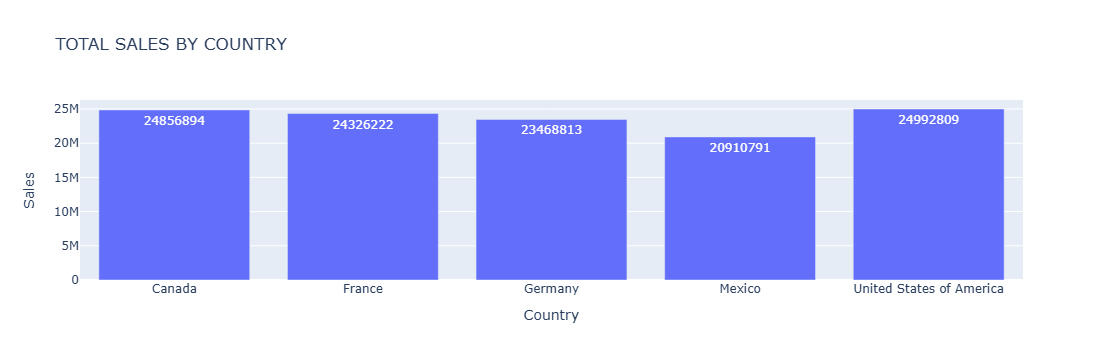

In [96]:
fig = px.bar(
    a,
    x="Country",
    y="Sales",
    text="Sales",
    title="TOTAL SALES BY COUNTRY"
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Sales"
)

fig.show()

In [55]:
#rounding off
data[["Gross Sales","Discounts","Cogs","Profit","Units Sold"]] = data[["Gross Sales","Discounts","Cogs",
                                                                       "Profit","Units Sold"]].round()

In [56]:
#converting to integer 
data[["Gross Sales","Discounts","Cogs","Profit","Units Sold"]] = data[["Gross Sales","Discounts","Cogs",
                                                                       "Profit","Units Sold"]].astype(int)

In [57]:
data.dtypes

Segment                  object
Country                  object
Product                  object
Discount Band            object
Units Sold                int32
Manufacturing             int64
Sale Price                int64
Gross Sales               int32
Discounts                 int32
Sales                     int32
Cogs                      int32
Profit                    int32
Date             datetime64[ns]
Month Number              int64
Month Name               object
Year                      int64
dtype: object

In [58]:
#get the total profits and units sola by products
b = data.groupby("Product").sum(numeric_only=True)[["Profit","Units Sold"]].reset_index()
b

,Product,Profit,Units Sold
0,Amarilla,2803448,153807
1,Carretera,1817410,143641
2,Montana,2112387,152485
3,Paseo,4771600,332491
4,VTT,3027743,166228
5,Velo,2292450,159125


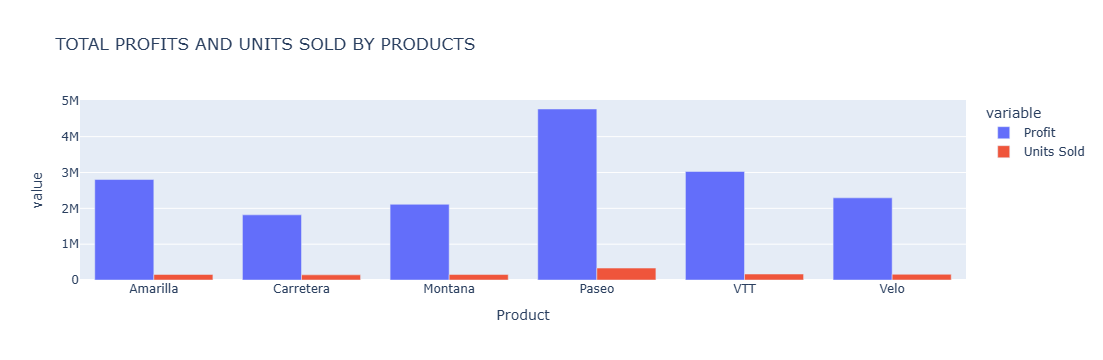

In [98]:
fig = px.bar(
    b,
    x="Product",
    y=["Profit", "Units Sold"],
    title="TOTAL PROFITS AND UNITS SOLD BY PRODUCTS",
    barmode="group"
)

fig.show()

In [60]:
#get the total counts of products by segment
c = data.groupby("Segment").count()["Units Sold"].reset_index()
c

,Segment,Units Sold
0,Channel Partners,90
1,Enterprise,100
2,Government,270
3,Midmarket,94
4,Small Business,100


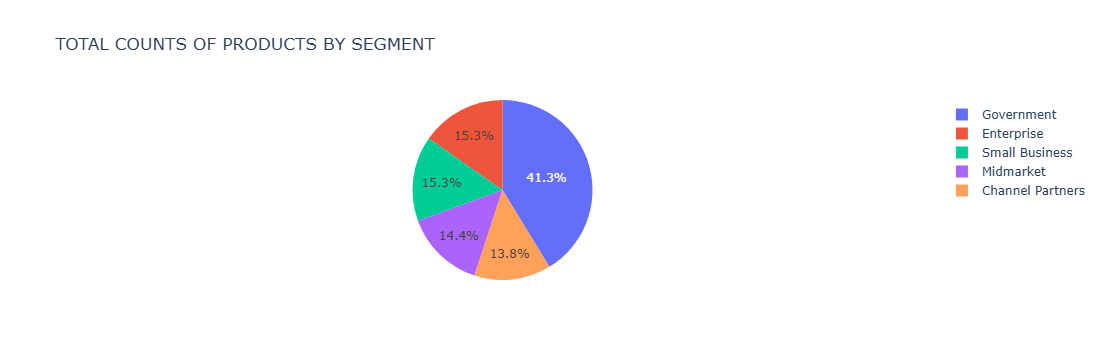

In [100]:
fig = px.pie(
    c,
    names="Segment",
    values="Units Sold",
    title="TOTAL COUNTS OF PRODUCTS BY SEGMENT"
)

fig.show()

In [62]:
#get the total discounts by discounts band
d = data.groupby("Discount Band").sum(numeric_only=True)["Discounts"].reset_index()
d

,Discount Band,Discounts
0,High,5304354
1,Low,885290
2,Medium,2997887


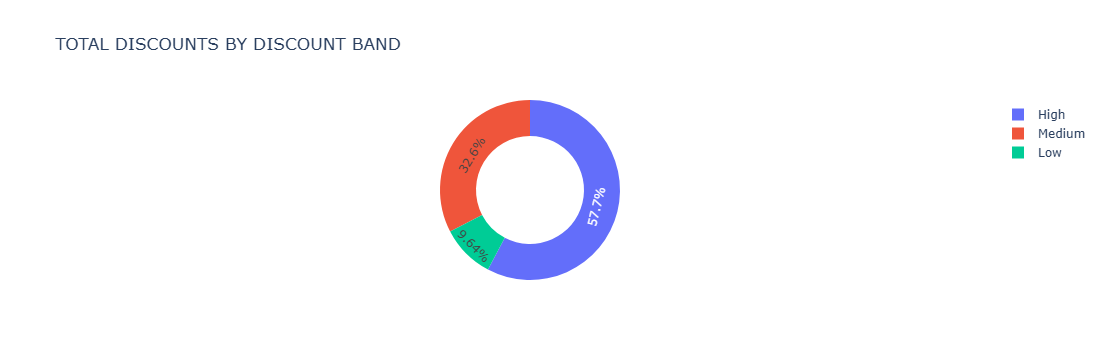

In [102]:
fig = px.pie(
    d,
    names="Discount Band",
    values="Discounts",
    hole=0.6,
    title="TOTAL DISCOUNTS BY DISCOUNT BAND"
)

fig.show()

In [64]:
#get the total cost of goods sold by products
e = data.groupby("Product").count()["Cogs"].reset_index()
e

,Product,Cogs
0,Amarilla,90
1,Carretera,86
2,Montana,89
3,Paseo,186
4,VTT,102
5,Velo,101


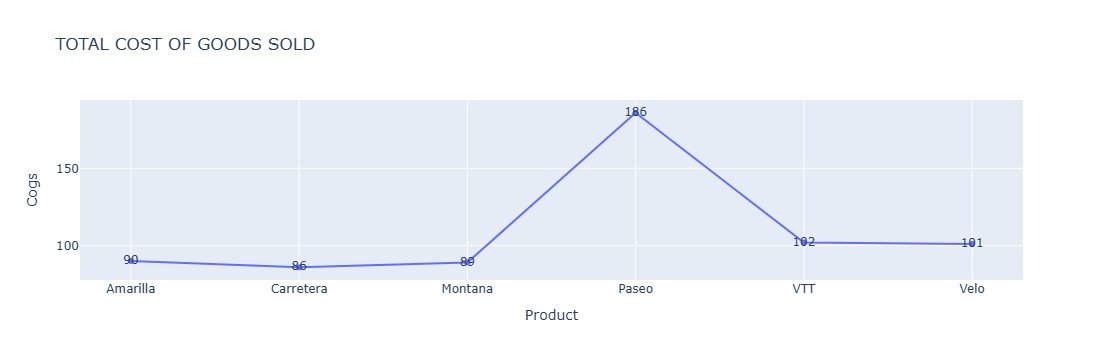

In [104]:
fig = px.line(
    e,
    x="Product",
    y="Cogs",
    text="Cogs",
    title="TOTAL COST OF GOODS SOLD",
    markers=True
)

fig.update_layout(
    xaxis_title="Product",
    yaxis_title="Cogs"
)

fig.show()